
<h1 align="center"> Introduction to Statistics with Python </h1>
<h3 align="center">(Notes below have been based on previous course by Sam Cohen)






#### MSc Mathematical and Computational Finance
#### Mathematical Institute
#### University of Oxford


**Course Term:** Michaelmas (2022-2023)

**Lecturer:** Katia Babbar

**email:** katia.babbar@maths.ox.ac.uk

**Course Overview:**  6hrs MT


# Examples of Exploring Data using Python

An Introductory course to Python will be explored by Riaz Ahmad. Riaz will provide a broad overview of the language and explore many examples and key packages. 

The suggestion here will be to install "Anaconda" as a first step. Anaconda is a free package manager, environment manager and collection of open source packages. See notes for installation from Riaz. 


Python
===

Python is a popular general purpose programming language
which is well suited to a wide range of problems.

Recent developments have extended Python's range of
applicability to econometrics, statistics, and general numerical
analysis.

Python is free and open source.

Anaconda
====

Anaconda is a free package manager, environment manager,
and collection of open source packages.

Anaconda includes both the core Python interpreter and
standard libraries.

Several banks use Anaconda nowadays as the standard Python
environment.

Anaconda includes also IPython notebooks (now known as
Jupyter notebooks).

Standard libraries, included in Anaconda

NumPy (http://www.numpy.org): library used to handle (large) arrays.
    
SciPy (http://www.scipy.org): library containing many useful scientific functions, including important statistical ones.
    
matplotlib (http://matplotlib.sourceforge.net): library used to plot.
    
pandas (http://pandas.sourceforge.net): library to analyze efficiently and fast large datasets; in particular also financial time series.
    
stats models (http://statsmodels.sourceforge.net): library to estimate and perform statistical tests.
    
IPython (http://www.ipython.org): shell, or browser-based: development environment.
        
Spyder (http://pythonhosted.org/spyder): interactive development environment.

Financial Data Sets
====
<br>

* There are a series of free available resources of financial data in the web.    
* These can be usually downloaded in csv files and subsequently imported as "pandas dataframes". 
* Dataframes are special data structures in Python which will be introduced more formally during the Python course. 
* For the time being, view them as useful indexed tables which facilitate data analysis and have some useful inbuilt methods which we will explore next.  



Reading data files into Pandas DataFrame
====
Some Python packages assist in the downloading of financial data and subsequent assingment of this data to a dataframe. One such package is "pandas_datareader". 

In [4]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math as m
import scipy as sp

In [2]:
start_date = '2010-01-01'
end_date = '2019-08-14'
MyData = pd_data.DataReader('GOOG','yahoo',start_date,end_date)


Pandas is a great package to handle data. Pandas dataframes are similar to R dataframes. As a first-order approximation we can think of them like an Excel sheet.

Some commonly used functions can be accessed to provide standard information on data (size, data type, info head, info tail, etc), access data and also execute some basic statistics.

 
Useful Data Information from Data Frames (df):
====

| Command | Brief Description |
| --- | --- |
| df.head() | displays first 5 rows (or "n" if specified as param) |
| df.tail() | displays last 5 rows (or "n" if specified as param) |
| df.shape| (num rows, num columns)  |
| df.info() | detailed info on all df |
| df.index | describes index |

| Summary and Functions | Brief Description |
| --- | --- |
| df.sum() | displays first 5 rows (or "n" if specified as param) |
| df.min()/df.max() | Min/Max value |
| df.idxmin()/df.idxmax()| Min/Max index value |
| df.mean() | Mean of values|
| df.median() | Median of values|
| df.std() | Standard Deviation of values 
| df.describe() | Summary statistics|



In [3]:
#MyData.to_csv("data_snapshot.csv")

In [4]:
MyData.shape 

(2420, 6)

In [5]:
MyData.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2010-01-04,15.678981,15.547723,15.615220,15.610239,78541293.0,15.610239
2010-01-05,15.637387,15.480475,15.620949,15.541497,120638494.0,15.541497
2010-01-06,15.588072,15.102393,15.588072,15.149715,159744526.0,15.149715
2010-01-07,15.193053,14.760922,15.178109,14.797037,257533695.0,14.797037
2010-01-08,15.024933,14.672753,14.744733,14.994298,189680313.0,14.994298


* The "index" is a way to access any data point across the dataframe
* Rows and columns both have indexes, rows indices are called as "index" 
* Columns are genearlly accessed via their column names

In [5]:
MyData.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2019-08-01', '2019-08-02', '2019-08-05', '2019-08-06',
               '2019-08-07', '2019-08-08', '2019-08-09', '2019-08-12',
               '2019-08-13', '2019-08-14'],
              dtype='datetime64[ns]', name='Date', length=2420, freq=None)

In [6]:
type(MyData)

pandas.core.frame.DataFrame

In [7]:
MyData.columns

Index(['High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close'], dtype='object')

In [8]:
len(MyData)

2420

In [9]:
MyData.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2420 entries, 2010-01-04 to 2019-08-14
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       2420 non-null   float64
 1   Low        2420 non-null   float64
 2   Open       2420 non-null   float64
 3   Close      2420 non-null   float64
 4   Volume     2420 non-null   float64
 5   Adj Close  2420 non-null   float64
dtypes: float64(6)
memory usage: 132.3 KB


In [11]:
MyData.head() #defaults to 5 rows

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2010-01-04,15.678981,15.547723,15.615220,15.610239,78541293.0,15.610239
2010-01-05,15.637387,15.480475,15.620949,15.541497,120638494.0,15.541497
2010-01-06,15.588072,15.102393,15.588072,15.149715,159744526.0,15.149715
2010-01-07,15.193053,14.760922,15.178109,14.797037,257533695.0,14.797037
2010-01-08,15.024933,14.672753,14.744733,14.994298,189680313.0,14.994298


In [10]:
MyData.head(20) # or we can specify numbers to be be displayed

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2010-01-04,15.678981,15.547723,15.615220,15.610239,78541293.0,15.610239
2010-01-05,15.637387,15.480475,15.620949,15.541497,120638494.0,15.541497
2010-01-06,15.588072,15.102393,15.588072,15.149715,159744526.0,15.149715
2010-01-07,15.193053,14.760922,15.178109,14.797037,257533695.0,14.797037
2010-01-08,15.024933,14.672753,14.744733,14.994298,189680313.0,14.994298
2010-01-11,15.055070,14.795543,15.055070,14.971633,289597429.0,14.971633
2010-01-12,14.898158,14.645107,14.885456,14.706875,194859654.0,14.706875
2010-01-13,14.654571,14.293923,14.358431,14.622441,260838034.0,14.622441
2010-01-14,14.799528,14.515841,14.542989,14.691184,170239717.0,14.691184


In [11]:
df = pd.read_csv("FRB_H15.csv")
df

,Series Description,"Market yield on U.S. Treasury securities at 1-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 6-month constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 1-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 2-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 3-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 5-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 7-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 10-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 20-year constant maturity, quoted on investment basis","Market yield on U.S. Treasury securities at 30-year constant maturity, quoted on investment basis"
0,Unit:,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year,Percent:_Per_Year
1,Multiplier:,1,1,1,1,1,1,1,1,1,1,1
2,Currency:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Unique Identifier:,H15/H15/RIFLGFCM01_N.B,H15/H15/RIFLGFCM03_N.B,H15/H15/RIFLGFCM06_N.B,H15/H15/RIFLGFCY01_N.B,H15/H15/RIFLGFCY02_N.B,H15/H15/RIFLGFCY03_N.B,H15/H15/RIFLGFCY05_N.B,H15/H15/RIFLGFCY07_N.B,H15/H15/RIFLGFCY10_N.B,H15/H15/RIFLGFCY20_N.B,H15/H15/RIFLGFCY30_N.B
4,Time Period,RIFLGFCM01_N.B,RIFLGFCM03_N.B,RIFLGFCM06_N.B,RIFLGFCY01_N.B,RIFLGFCY02_N.B,RIFLGFCY03_N.B,RIFLGFCY05_N.B,RIFLGFCY07_N.B,RIFLGFCY10_N.B,RIFLGFCY20_N.B,RIFLGFCY30_N.B
...,...,...,...,...,...,...,...,...,...,...,...,...
15583,2021-09-17,0.06,0.04,0.05,0.07,0.23,0.47,0.88,1.17,1.37,1.85,1.91
15584,2021-09-20,0.06,0.04,0.05,0.07,0.23,0.45,0.83,1.12,1.31,1.79,1.85
15585,2021-09-21,0.05,0.03,0.04,0.07,0.22,0.46,0.84,1.13,1.33,1.81,1.86
15586,2021-09-22,0.04,0.03,0.05,0.08,0.25,0.48,0.86,1.13,1.32,1.78,1.84


In [12]:
closeData = MyData["Close"]
openData = MyData["Open"]
pct_daily_simple_rtn = (closeData - openData)/openData

In [13]:
pct_daily_simple_rtn.head()

Date
2010-01-04   -0.000319
2010-01-05   -0.005086
2010-01-06   -0.028121
2010-01-07   -0.025107
2010-01-08    0.016926
dtype: float64

In [14]:
pct_daily_simple_rtn.describe()

count    2420.000000
mean       -0.000112
std         0.011816
min        -0.080128
25%        -0.006115
50%        -0.000074
75%         0.006870
max         0.052006
dtype: float64

Plotting is very easy in Python!
====

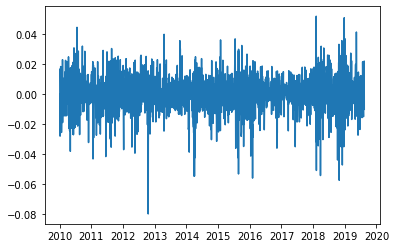

In [15]:
plt.plot(pct_daily_simple_rtn)

And visualization can always be improved upon by specifying special arguments...
====

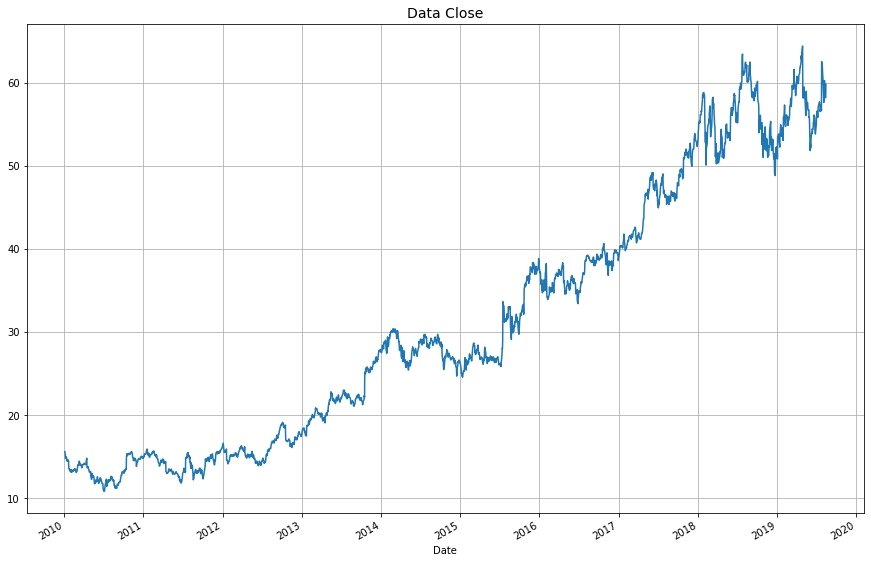

In [16]:
MyData['Close'].plot(figsize = (15, 10), grid = True)
plt.title('Data Close', fontsize=14)
plt.show()

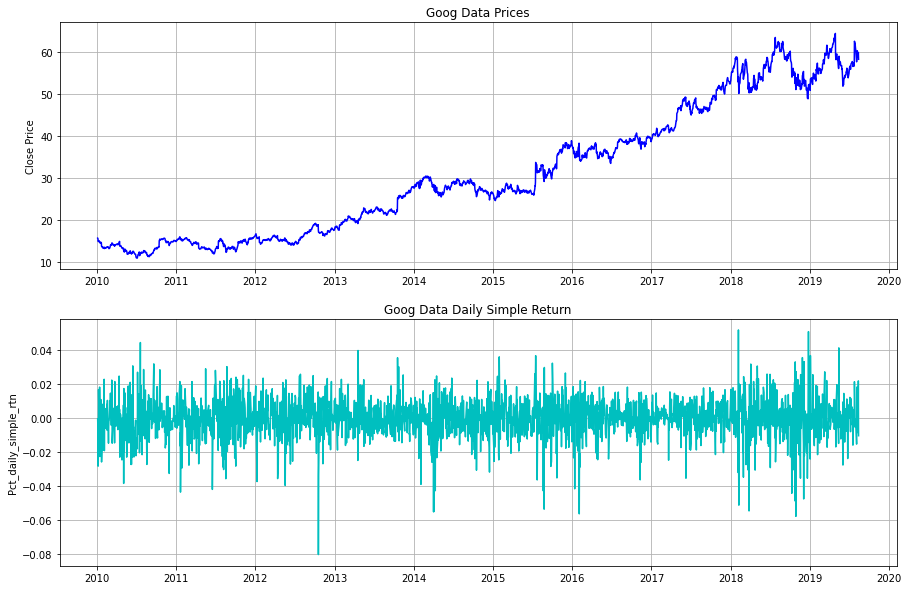

In [17]:
plt.figure(1, figsize=(15,10)) # overall dimensions 
plt.subplot(2,1, 1) # 2 by 1 and plot 1
plt.title('Goog Data Prices')
plt.plot(MyData['Close'], 'b')
plt.ylabel('Close Price')
plt.grid()
plt.subplot(2,1, 2) # 2 by 1 and plot 2
plt.plot(pct_daily_simple_rtn, 'c')
plt.title('Goog Data Daily Simple Return')
plt.ylabel('Pct_daily_simple_rtn')
plt.grid()


In [18]:
%%time
DataLogRtn = np.log(MyData).diff().dropna() #diff = log(p(t))- log(p(t-1))= log(p(t)/p(t-1)),continuosly compounded return


CPU times: user 2.51 ms, sys: 691 µs, total: 3.2 ms
Wall time: 3.5 ms


In [19]:
DataLogRtn.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2010-01-05,-0.002656,-0.004335,0.000367,-0.004413,0.429174,-0.004413
2010-01-06,-0.003159,-0.024726,-0.002107,-0.025532,0.280777,-0.025532
2010-01-07,-0.025668,-0.022870,-0.026652,-0.023555,0.477575,-0.023555
2010-01-08,-0.011127,-0.005991,-0.028968,0.013243,-0.305810,0.013243
2010-01-11,0.002004,0.008334,0.020829,-0.001513,0.423152,-0.001513


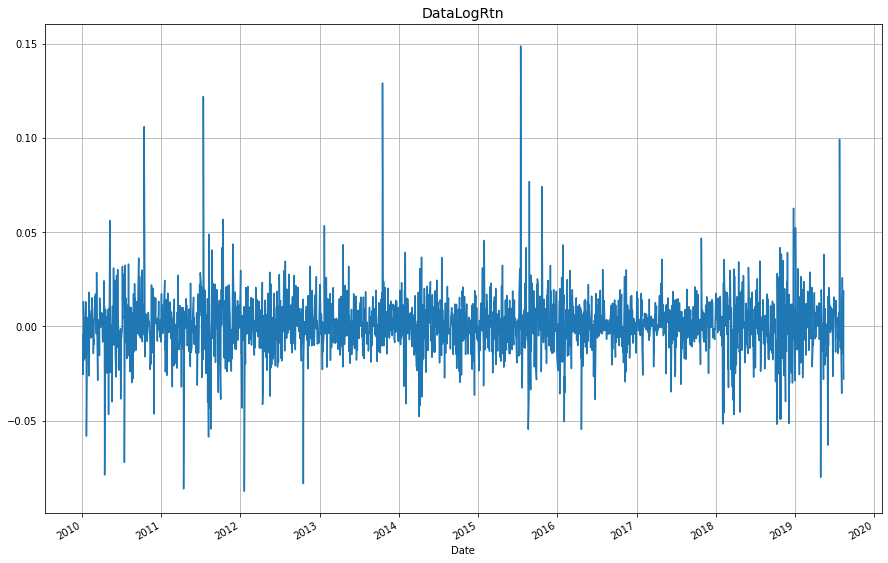

In [20]:
DataLogRtn['Close'].plot(figsize = (15, 10), grid = True)
plt.title('DataLogRtn', fontsize=14)
plt.show()

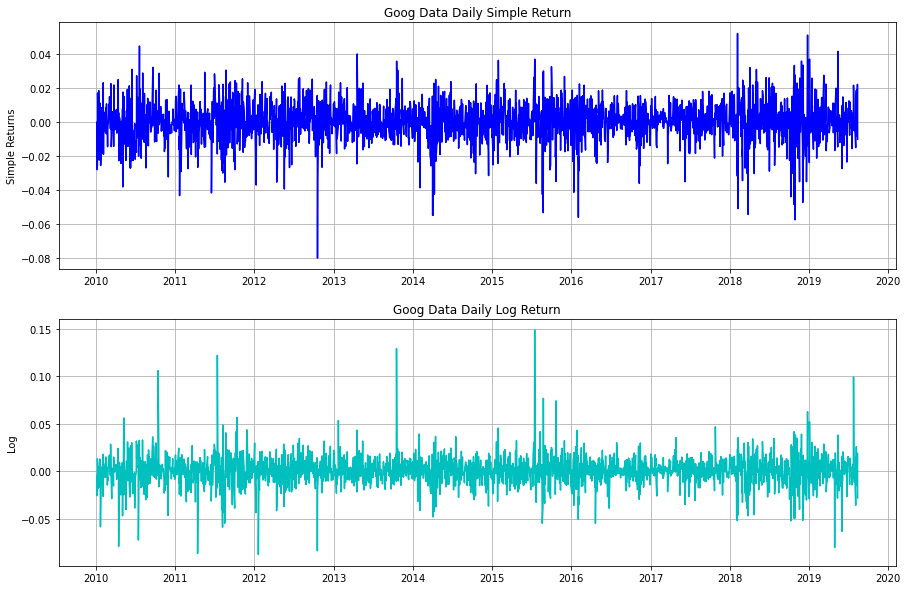

In [21]:
plt.figure(1, figsize=(15,10)) # overall dimensions 
plt.subplot(2,1, 1) # 2 by 1 and plot 1
plt.title('Goog Data Daily Simple Return')
plt.plot(pct_daily_simple_rtn, 'b')
plt.ylabel('Simple Returns')
plt.grid()
plt.subplot(2,1, 2) # 2 by 1 and plot 2
plt.plot(DataLogRtn['Close'], 'c')
plt.title('Goog Data Daily Log Return')
plt.ylabel('Log')
plt.grid()

Basic Statistics on Data
====

In [22]:
DataLogRtn['Close'].describe()


count    2419.000000
mean        0.000544
std         0.015480
min        -0.087493
25%        -0.006610
50%         0.000437
75%         0.008395
max         0.148872
Name: Close, dtype: float64

Plotting histogram and guessing a distribution for the log returns...
====

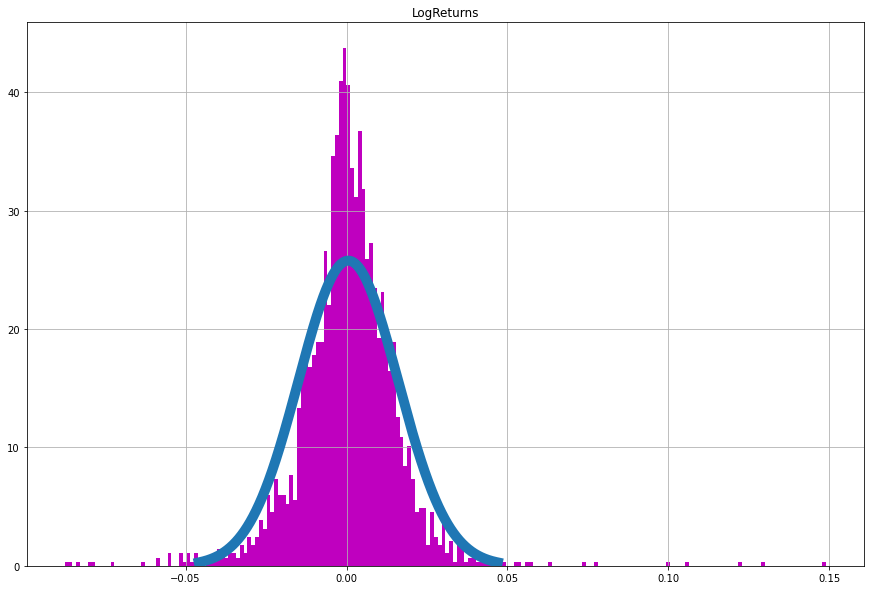

In [23]:
DataLogRtnClose = DataLogRtn['Close']
DataLogRtnClose.hist(bins = 200, figsize = (15 ,10), color='m', density = True)
plt.title('LogReturns')
mu = DataLogRtnClose.mean()
sigma = DataLogRtnClose.std()
kurt = DataLogRtnClose.kurt()
skew = DataLogRtnClose.skew()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 2419)
myplot = plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth= 10)
plt.show()

Are log returns for Goog really normal???
====

* A normally distributed random variable would have skew = 0 and kurtosis = 3.
* If skew is negative, the mode will be higher than the median and mean.
* Likewise, if the skew is positive, the mode will be less than that median and mean.
* When kurtosis is above 3, it's a sign of more likely extreme events ("fat tail").
* Conversely, a kurtosis below 3, indicates feweer outliers than the normal distribution.

In [26]:
kurt


11.267038794671123

In [27]:
skew


0.558466582093756

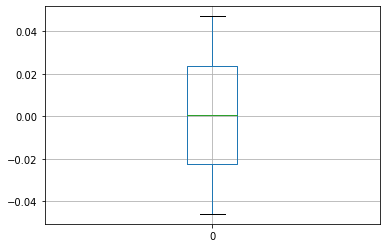

In [24]:
# Box plot for a normal distribution (notice symmetry adn values of quantiles)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 2419)
y = stats.norm.pdf(x, mu, sigma)
normDf = pd.DataFrame(x,y)
normBXP = normDf.boxplot()

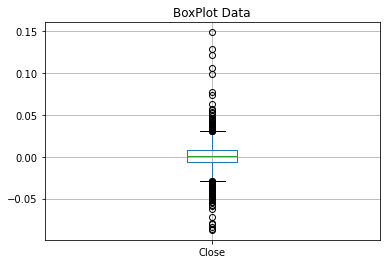

In [25]:
dataBXP = pd.DataFrame(DataLogRtnClose).boxplot()
plt.title('BoxPlot Data')
plt.show()

Exercises
===

1. Repeat EDA for another 4 sets of data (your choice!) and compare histograms as above, for the 4 stocks in a single figure.
2. Similar exercise for 4 stocks from the banking sector, going back 15 years if you can.
3. Divide period for the time serise for Google in 3. Examine similar stats on the different periods. Are there any conclusions you can draw?

Example for Hypothesis Testing
====


In [26]:
print(DataLogRtnClose.mean(), DataLogRtnClose.std()) 

0.0005441122054476549 0.01547970038465901


In [27]:
x_bar = DataLogRtnClose.mean()
s = DataLogRtnClose.std()
n = len(x)
se = s/m.sqrt(n)
mu0 = 0

In [28]:
print(sp.stats.ttest_1samp(DataLogRtnClose, 0 )) 
#H0= the returns came from a population of mean 0, Ha = they have not

Ttest_1sampResult(statistic=1.7287964088290297, pvalue=0.08397318484811372)


In [29]:
t_manual = (x_bar - mu0)/se
t_manual

1.7287964088290293

scipy.stats.ttest_1samp(sample data, popmean, axis =0)[source]
====

Calculates the T-test for the mean of ONE group of scores.
This is a two-sided test for the null hypothesis that the expected value (mean) of a sample of independent observations "sample data" is equal to the given population mean.

t-Test for Kurtosis and Skew
===


In [34]:
skew = DataLogRtnClose.skew()
n=len(DataLogRtnClose)
t_skew = skew/m.sqrt(6/n)
p_value_s = sp.stats.norm.sf(abs(t_skew))*2 #twosided
print(t_skew, p_value_s)

11.213456421491626 3.5024362196793254e-29


In [35]:
kurt = DataLogRtnClose.kurt()
n=len(DataLogRtnClose)
t_kurt = (kurt-3)/m.sqrt(24/n)
p_value_k = sp.stats.norm.sf(abs(t_kurt))*2 #twosided
print(t_kurt, p_value_k)

82.99697979355761 0.0


Jarque-Bera Normality Test
---

In [36]:
sp.stats.jarque_bera(DataLogRtnClose) #returns the JB value and p-value

Jarque_beraResult(statistic=12862.27308180667, pvalue=0.0)

QQ Plot
===


0.0005441122054476549 0.015479700384659009


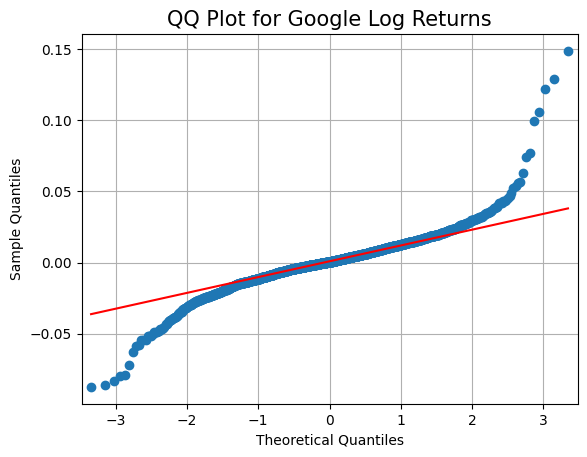

In [38]:
import statsmodels.api as sm
mean = DataLogRtnClose.mean()
stdDev= DataLogRtnClose.std()
print(mean,stdDev)
fig = sm.qqplot(DataLogRtnClose, line = 'q')
plt.title('QQ Plot for Google Log Returns', fontsize=15)
plt.grid()
plt.show()